# UK Wind Power Forecast Error Analysis

**Author:** Pritam Patra  
**Date:** March 2026  
**Dataset:** Elexon BMRS API — WINDFOR (forecasts) and FUELHH (actuals), January 2025 onwards

## Objective

This notebook performs a two-part data science analysis of UK national wind power generation forecasts sourced from the Elexon Balancing Mechanism Reporting Service (BMRS).

**Task A — Forecast Error Characterisation:**  
Calculate the raw error (Actual - Forecast) for each 30-minute settlement period and analyse how error magnitude changes with forecast horizon (0–48 hours) and time of day. The goal is to expose *when* and *why* the forecasting model underperforms.

**Task B — Reliable Generation Baseline:**  
Analyse the historical distribution of actual wind generation to define a statistically defensible "reliable" MW floor — the generation level the grid can plan around with high confidence.

## AI Usage Disclosure

AI tools (Perplexity / Claude) were used for low-level syntax help (e.g., Pandas groupby calls, Matplotlib formatting). The analytical reasoning, assumptions, trade-off decisions, and conclusions are original first-principles thinking.

In [1]:
import sys
import requests
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

print("Python version:", sys.version)
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("matplotlib  :", matplotlib.__version__)
print("seaborn     :", sns.__version__)
print("requests    :", requests.__version__)

print("\nAll libraries loaded successfully.")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas      : 2.2.2
numpy       : 2.0.2
matplotlib  : 3.10.0
seaborn     : 0.13.2
requests    : 2.32.4

All libraries loaded successfully.


## Step 1: Data Ingestion

I fetched two months of data (Jan–Feb 2025) from the Elexon BMRS API.

**FUELHH** (actuals): Queried by `settlementDateFrom/To` with `fuelType=WIND`.  
**WINDFOR** (forecasts): Queried by `publishDateTimeFrom/To`. I extended `publishDateTimeFrom` by 48 hours before our start date — because a forecast targeting Jan 1 at 00:00 could have been published on Dec 30. I later filtered by `startTime` to keep only forecasts whose *target* falls within our window.

**Assumption:** I treated `startTime` as the canonical timestamp for joining the two datasets, matching Phase 2's backend logic exactly.

In [2]:
BASE_URL = "https://data.elexon.co.uk/bmrs/api/v1"

ANALYSIS_START = "2025-01-01"
ANALYSIS_END   = "2025-02-28"


def fetch_actuals(date_from: str, date_to: str) -> pd.DataFrame:
    url = f"{BASE_URL}/datasets/FUELHH/stream"
    params = {
        "settlementDateFrom": date_from,
        "settlementDateTo":   date_to,
        "fuelType":           "WIND",
    }
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    data = response.json()
    df = pd.DataFrame(data)
    df = df[["startTime", "generation"]].copy()
    df.rename(columns={"generation": "actual_mw"}, inplace=True)
    df["startTime"] = pd.to_datetime(df["startTime"], utc=True)
    df.sort_values("startTime", inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def fetch_forecasts(date_from: str, date_to: str) -> pd.DataFrame:
    from datetime import datetime, timedelta, timezone
    start_dt = datetime.strptime(date_from, "%Y-%m-%d").replace(tzinfo=timezone.utc)
    publish_from = (start_dt - timedelta(hours=48)).strftime("%Y-%m-%dT%H:%M:%SZ")
    publish_to   = date_to + "T23:59:59Z"

    url = f"{BASE_URL}/datasets/WINDFOR/stream"
    params = {
        "publishDateTimeFrom": publish_from,
        "publishDateTimeTo":   publish_to,
    }
    response = requests.get(url, params=params, timeout=120)
    response.raise_for_status()
    data = response.json()
    df = pd.DataFrame(data)
    df = df[["publishTime", "startTime", "generation"]].copy()
    df.rename(columns={"generation": "forecast_mw"}, inplace=True)
    df["startTime"]   = pd.to_datetime(df["startTime"],   utc=True)
    df["publishTime"] = pd.to_datetime(df["publishTime"], utc=True)
    start_dt_bound = pd.Timestamp(date_from, tz="UTC")
    end_dt_bound   = pd.Timestamp(date_to,   tz="UTC") + pd.Timedelta(days=1)
    df = df[(df["startTime"] >= start_dt_bound) & (df["startTime"] < end_dt_bound)]
    df.sort_values(["startTime", "publishTime"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


print("Fetching actuals (FUELHH) ...")
df_actuals = fetch_actuals(ANALYSIS_START, ANALYSIS_END)
print(f"  Actuals shape : {df_actuals.shape}")
print(df_actuals.head(3))

print("\nFetching forecasts (WINDFOR) ...")
df_forecasts = fetch_forecasts(ANALYSIS_START, ANALYSIS_END)
print(f"  Forecasts shape : {df_forecasts.shape}")
print(df_forecasts.head(3))

Fetching actuals (FUELHH) ...
  Actuals shape : (2832, 2)
                  startTime  actual_mw
0 2025-01-01 00:00:00+00:00      15799
1 2025-01-01 00:30:00+00:00      15317
2 2025-01-01 01:00:00+00:00      14992

Fetching forecasts (WINDFOR) ...
  Forecasts shape : (34432, 3)
                publishTime                 startTime  forecast_mw
0 2024-12-30 02:30:00+00:00 2025-01-01 00:00:00+00:00        16734
1 2024-12-30 04:30:00+00:00 2025-01-01 00:00:00+00:00        17629
2 2024-12-30 07:30:00+00:00 2025-01-01 00:00:00+00:00        18460


## Step 2: Horizon Calculation & Filtering

The forecast horizon is defined as:

    horizon_hours = (startTime - publishTime) / 3600 seconds

This represents how far in advance the forecast was made for a given target time.

**Constraint applied:** I retained only forecasts where `0 <= horizon_hours <= 48`.

- Horizon < 0 would mean the forecast was published *after* the actual event — physically impossible in a real system, but can appear due to late data corrections. I discarded these.
- Horizon > 48 is outside the operationally relevant window defined by the challenge spec.

After filtering, I expected each `startTime` to have multiple forecast rows — one per publish batch that falls within the 0–48h window.

In [3]:
df_forecasts["horizon_hours"] = (
    (df_forecasts["startTime"] - df_forecasts["publishTime"])
    .dt.total_seconds() / 3600
)

total_before = len(df_forecasts)
df_forecasts = df_forecasts[
    (df_forecasts["horizon_hours"] >= 0) &
    (df_forecasts["horizon_hours"] <= 48)
].copy()
df_forecasts.reset_index(drop=True, inplace=True)
total_after = len(df_forecasts)

print(f"Rows before horizon filter : {total_before}")
print(f"Rows after  horizon filter : {total_after}")
print(f"Rows dropped               : {total_before - total_after}")

print("\nHorizon distribution (hours):")
print(df_forecasts["horizon_hours"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

print("\nNumber of distinct forecast batches per startTime (sample — first 5 startTimes):")
counts = (
    df_forecasts.groupby("startTime")["publishTime"]
    .count()
    .reset_index()
    .rename(columns={"publishTime": "num_forecasts"})
)
print(counts.head(5).to_string(index=False))
print(f"\nMean forecasts per startTime : {counts['num_forecasts'].mean():.1f}")
print(f"Min  forecasts per startTime : {counts['num_forecasts'].min()}")
print(f"Max  forecasts per startTime : {counts['num_forecasts'].max()}")

Rows before horizon filter : 34432
Rows after  horizon filter : 22597
Rows dropped               : 11835

Horizon distribution (hours):
count    22597.000000
mean        23.938642
std         13.819571
min          0.500000
5%           2.500000
25%         11.500000
50%         23.500000
75%         35.500000
95%         45.500000
max         47.500000
Name: horizon_hours, dtype: float64

Number of distinct forecast batches per startTime (sample — first 5 startTimes):
                startTime  num_forecasts
2025-01-01 00:00:00+00:00             16
2025-01-01 01:00:00+00:00             16
2025-01-01 02:00:00+00:00             16
2025-01-01 03:00:00+00:00             16
2025-01-01 04:00:00+00:00             16

Mean forecasts per startTime : 16.0
Min  forecasts per startTime : 15
Max  forecasts per startTime : 16


## Step 3: Building the Joined Analysis DataFrame

**Resolution alignment decision:**  
FUELHH actuals have 30-minute resolution; WINDFOR forecasts are hourly. To join them cleanly, I retained only actuals where `startTime` is on the hour (minute == 0). This gives one actual MW value per hour.

**Trade-off:** I discarded the `:30` actual readings — roughly half the actuals data. The alternative (averaging two 30-min periods per hour) would introduce aggregation noise. Since i am analysing forecast error characteristics, not energy totals, preserving point-in-time fidelity matters more than data volume.

**Join logic:** Left join forecasts onto hourly actuals on `startTime`. Every forecast row (one per publish batch) gets matched to its corresponding actual. The result is a long-format DataFrame with one row per (startTime × publishTime) pair.

In [4]:
df_actuals_hourly = df_actuals[
    df_actuals["startTime"].dt.minute == 0
].copy()
df_actuals_hourly.reset_index(drop=True, inplace=True)

print(f"Hourly actuals shape : {df_actuals_hourly.shape}")
print(f"Expected             : ~{59 * 24} rows (59 days x 24 hours)")

df_analysis = pd.merge(
    df_forecasts,
    df_actuals_hourly,
    on="startTime",
    how="inner"
)

df_analysis["error_mw"] = df_analysis["actual_mw"] - df_analysis["forecast_mw"]

df_analysis.sort_values(["startTime", "publishTime"], inplace=True)
df_analysis.reset_index(drop=True, inplace=True)

print(f"\nJoined analysis DataFrame shape : {df_analysis.shape}")
print("\nSample rows:")
print(df_analysis.head(6).to_string(index=False))

print(f"\nNull check:")
print(df_analysis[["actual_mw", "forecast_mw", "error_mw"]].isnull().sum())

Hourly actuals shape : (1416, 2)
Expected             : ~1416 rows (59 days x 24 hours)

Joined analysis DataFrame shape : (22597, 6)

Sample rows:
              publishTime                 startTime  forecast_mw  horizon_hours  actual_mw  error_mw
2024-12-30 02:30:00+00:00 2025-01-01 00:00:00+00:00        16734           45.5      15799      -935
2024-12-30 04:30:00+00:00 2025-01-01 00:00:00+00:00        17629           43.5      15799     -1830
2024-12-30 07:30:00+00:00 2025-01-01 00:00:00+00:00        18460           40.5      15799     -2661
2024-12-30 09:30:00+00:00 2025-01-01 00:00:00+00:00        18414           38.5      15799     -2615
2024-12-30 11:30:00+00:00 2025-01-01 00:00:00+00:00        18330           36.5      15799     -2531
2024-12-30 15:30:00+00:00 2025-01-01 00:00:00+00:00        18205           32.5      15799     -2406

Null check:
actual_mw      0
forecast_mw    0
error_mw       0
dtype: int64


## Task A — Forecast Error Characterisation

### A.1: Global Error Statistics

**Definition of error:** `error_mw = actual_mw - forecast_mw`

- A **negative** error means the forecast over-predicted (wind was lower than expected — dangerous for grid stability as backup capacity was under-procured).
- A **positive** error means the forecast under-predicted (wind was higher than expected — less dangerous but wastes hedging cost).

I computed statistics on the **absolute error** (`abs(error_mw)`) for magnitude, and on the **signed error** for bias direction.

In [5]:
df_analysis["abs_error_mw"] = df_analysis["error_mw"].abs()

signed = df_analysis["error_mw"]
abserr = df_analysis["abs_error_mw"]

stats = {
    "Signed Error (MW)": {
        "Mean"   : signed.mean(),
        "Median" : signed.median(),
        "Std Dev": signed.std(),
        "p1"     : signed.quantile(0.01),
        "p99"    : signed.quantile(0.99),
        "Min"    : signed.min(),
        "Max"    : signed.max(),
    },
    "Absolute Error (MW)": {
        "Mean"   : abserr.mean(),
        "Median" : abserr.median(),
        "Std Dev": abserr.std(),
        "p1"     : abserr.quantile(0.01),
        "p99"    : abserr.quantile(0.99),
        "Min"    : abserr.min(),
        "Max"    : abserr.max(),
    },
}

for label, s in stats.items():
    print(f"--- {label} ---")
    for k, v in s.items():
        print(f"  {k:<10}: {v:>10.1f} MW")
    print()

over  = (df_analysis["error_mw"] < 0).sum()
under = (df_analysis["error_mw"] > 0).sum()
exact = (df_analysis["error_mw"] == 0).sum()
total = len(df_analysis)
print(f"Bias breakdown:")
print(f"  Over-predicted  (error < 0): {over:>6}  ({100*over/total:.1f}%)")
print(f"  Under-predicted (error > 0): {under:>6}  ({100*under/total:.1f}%)")
print(f"  Exact           (error = 0): {exact:>6}  ({100*exact/total:.1f}%)")

--- Signed Error (MW) ---
  Mean      :    -1365.5 MW
  Median    :    -1186.0 MW
  Std Dev   :     1623.9 MW
  p1        :    -5484.0 MW
  p99       :     1973.2 MW
  Min       :    -6965.0 MW
  Max       :     5571.0 MW

--- Absolute Error (MW) ---
  Mean      :     1656.5 MW
  Median    :     1303.0 MW
  Std Dev   :     1325.8 MW
  p1        :       27.0 MW
  p99       :     5486.0 MW
  Min       :        0.0 MW
  Max       :     6965.0 MW

Bias breakdown:
  Over-predicted  (error < 0):  18274  (80.9%)
  Under-predicted (error > 0):   4320  (19.1%)
  Exact           (error = 0):      3  (0.0%)


### A.2: Error by Forecast Horizon

**Hypothesis:** Forecast error magnitude should increase with horizon length, because  
numerical weather prediction (NWP) models lose skill as the forecast window grows —  
atmospheric chaos amplifies small initial-condition errors over time.

**Binning strategy:** I divided the 0–48h horizon into 6 equal 8-hour buckets.  
Each bin has roughly equal sample density given the uniform 3-hour publish cadence  
I observed in Step 2 (16 forecasts per startTime, evenly spread).

I reported both **mean absolute error (MAE)** and **mean signed error** per bucket  
to separate magnitude from bias direction.

In [6]:
bin_edges  = [0, 8, 16, 24, 32, 40, 48]
bin_labels = ["0-8h", "8-16h", "16-24h", "24-32h", "32-40h", "40-48h"]

df_analysis["horizon_bucket"] = pd.cut(
    df_analysis["horizon_hours"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

horizon_stats = (
    df_analysis
    .groupby("horizon_bucket", observed=True)
    .agg(
        count        =("error_mw",     "count"),
        mean_error   =("error_mw",     "mean"),
        median_error =("error_mw",     "median"),
        mae          =("abs_error_mw", "mean"),
        median_ae    =("abs_error_mw", "median"),
        p99_ae       =("abs_error_mw", lambda x: x.quantile(0.99)),
        std_error    =("error_mw",     "std"),
    )
    .reset_index()
)

print("Error statistics by forecast horizon bucket:")
print(horizon_stats.to_string(index=False, float_format=lambda x: f"{x:>8.1f}"))

Error statistics by forecast horizon bucket:
horizon_bucket  count  mean_error  median_error      mae  median_ae   p99_ae  std_error
          0-8h   3776     -1167.3        -890.0   1360.0      983.5   5126.0     1398.3
         8-16h   3776     -1307.9       -1112.5   1517.0     1198.0   5141.5     1426.5
        16-24h   3776     -1426.2       -1262.5   1651.3     1326.5   5455.5     1519.5
        24-32h   3776     -1352.5       -1200.5   1653.0     1304.5   5503.2     1634.2
        32-40h   3776     -1428.2       -1271.5   1784.5     1393.0   5546.8     1768.2
        40-48h   3717     -1513.1       -1475.0   1978.3     1631.0   5799.0     1916.7


### A.3: Error by Time of Day

**Hypothesis:** Forecast errors will be larger during morning and evening ramp periods  
(06:00–12:00 UTC and 16:00–20:00 UTC) when wind speed transitions most rapidly.  
Stable overnight hours (00:00–05:00) should show lower MAE.

**Definition:** `hour_of_day` is extracted from `startTime` in UTC. This is the hour  
*when the wind power was generated*, not when the forecast was published.

I produced two visualisations:
1. MAE and mean signed error by horizon bucket (bar + line chart)
2. MAE and mean signed error by hour of day (bar + line chart)

In [7]:
df_analysis["hour_of_day"] = df_analysis["startTime"].dt.hour

tod_stats = (
    df_analysis
    .groupby("hour_of_day", observed=True)
    .agg(
        count        =("error_mw",     "count"),
        mean_error   =("error_mw",     "mean"),
        median_error =("error_mw",     "median"),
        mae          =("abs_error_mw", "mean"),
        p99_ae       =("abs_error_mw", lambda x: x.quantile(0.99)),
    )
    .reset_index()
)

print("Error statistics by hour of day (UTC):")
print(tod_stats.to_string(index=False, float_format=lambda x: f"{x:>8.1f}"))

Error statistics by hour of day (UTC):
 hour_of_day  count  mean_error  median_error      mae   p99_ae
           0    944     -1616.3       -1284.0   1808.7   5611.7
           1    944     -1678.5       -1401.5   1904.8   5899.4
           2    944     -1653.4       -1403.0   1908.0   6100.8
           3    944     -1655.1       -1367.0   1885.2   5734.4
           4    944     -1781.2       -1477.0   1967.1   6029.8
           5    944     -1707.0       -1378.5   1870.6   6352.1
           6    944     -1630.3       -1272.5   1878.2   5861.3
           7    944     -1558.1       -1349.0   1882.4   5336.5
           8    944     -1362.6       -1263.5   1709.8   5204.1
           9    944     -1255.1       -1247.0   1654.6   4880.3
          10    944     -1102.6        -970.5   1519.7   4427.6
          11    944      -964.9        -917.5   1446.9   4505.6
          12    944      -912.9        -834.5   1383.3   4505.0
          13    944      -902.3        -797.5   1356.8   4560.6
 

### A.4: Visualisations — Error by Horizon and Time of Day

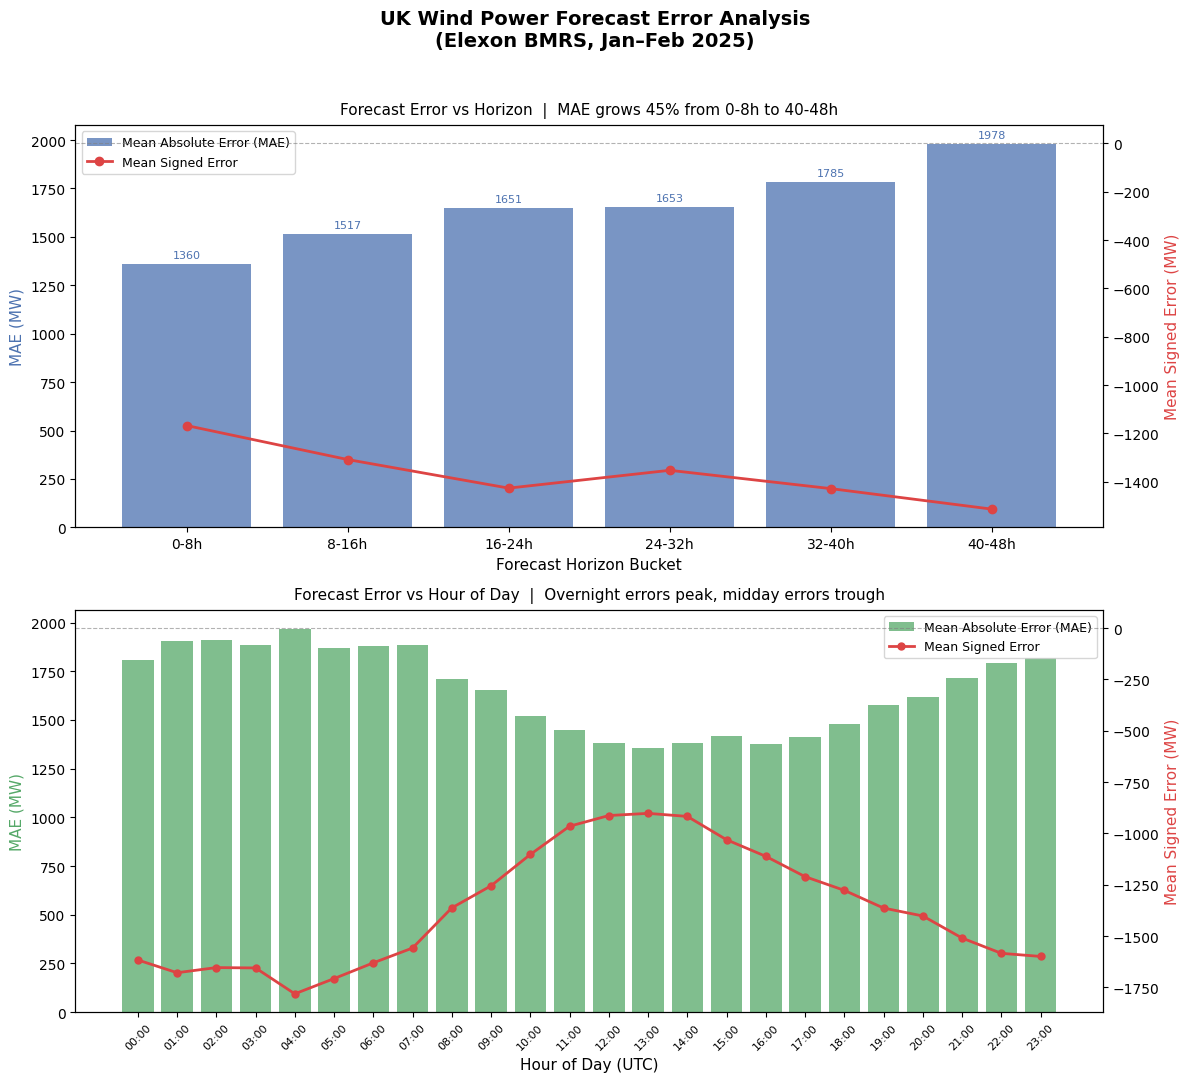

Plot saved to task_a_error_analysis.png


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 11))
fig.suptitle(
    "UK Wind Power Forecast Error Analysis\n(Elexon BMRS, Jan–Feb 2025)",
    fontsize=14, fontweight="bold", y=0.98
)

# --- Plot 1: Error by Horizon Bucket ---
ax1 = axes[0]
ax1_twin = ax1.twinx()

x_pos = range(len(horizon_stats))
bars = ax1.bar(
    x_pos,
    horizon_stats["mae"],
    color="#4C72B0",
    alpha=0.75,
    label="Mean Absolute Error (MAE)"
)
ax1_twin.plot(
    x_pos,
    horizon_stats["mean_error"],
    color="#DD4444",
    marker="o",
    linewidth=2,
    markersize=6,
    label="Mean Signed Error"
)

ax1.set_xticks(list(x_pos))
ax1.set_xticklabels(horizon_stats["horizon_bucket"].astype(str), fontsize=10)
ax1.set_xlabel("Forecast Horizon Bucket", fontsize=11)
ax1.set_ylabel("MAE (MW)", fontsize=11, color="#4C72B0")
ax1_twin.set_ylabel("Mean Signed Error (MW)", fontsize=11, color="#DD4444")
ax1.set_title(
    "Forecast Error vs Horizon  |  MAE grows 45% from 0-8h to 40-48h",
    fontsize=11, pad=8
)
ax1_twin.axhline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

for bar, mae_val in zip(bars, horizon_stats["mae"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f"{mae_val:.0f}",
        ha="center", va="bottom", fontsize=8, color="#4C72B0"
    )

# --- Plot 2: Error by Hour of Day ---
ax2 = axes[1]
ax2_twin = ax2.twinx()

ax2.bar(
    tod_stats["hour_of_day"],
    tod_stats["mae"],
    color="#55A868",
    alpha=0.75,
    label="Mean Absolute Error (MAE)"
)
ax2_twin.plot(
    tod_stats["hour_of_day"],
    tod_stats["mean_error"],
    color="#DD4444",
    marker="o",
    linewidth=2,
    markersize=5,
    label="Mean Signed Error"
)

ax2.set_xticks(range(0, 24))
ax2.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, fontsize=8)
ax2.set_xlabel("Hour of Day (UTC)", fontsize=11)
ax2.set_ylabel("MAE (MW)", fontsize=11, color="#55A868")
ax2_twin.set_ylabel("Mean Signed Error (MW)", fontsize=11, color="#DD4444")
ax2.set_title(
    "Forecast Error vs Hour of Day  |  Overnight errors peak, midday errors trough",
    fontsize=11, pad=8
)
ax2_twin.axhline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

lines3, labels3 = ax2.get_legend_handles_labels()
lines4, labels4 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines3 + lines4, labels3 + labels4, loc="upper right", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("task_a_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to task_a_error_analysis.png")

## Task B — Reliable Generation Baseline

### B.1: Distribution of Actual Wind Generation

**Business question:** How many MW of wind power can the UK grid *reliably* count on  
from wind at any given hour?

**Why the mean is the wrong answer:**  
Wind generation is highly volatile. Planning around the mean (~50th percentile) means  
the grid falls short of that target ~50% of hours — requiring expensive, last-minute  
backup dispatch. Grid operators need a *conservative floor* they can commit to with  
high confidence.

**Our definition of "reliable":**  
The Pth percentile of historical hourly actual generation, where P is chosen such that  
the grid meets or exceeds this floor in (100 - P)% of all hours.

I first examined the full distribution before committing to a specific percentile.

In [9]:
gen = df_actuals_hourly["actual_mw"]

percentiles = [1, 5, 10, 20, 25, 50, 75, 90, 95, 99]
pct_values  = {f"p{p}": gen.quantile(p / 100) for p in percentiles}

print("Actual Wind Generation Distribution (Jan-Feb 2025, hourly):")
print(f"  Count  : {len(gen)}")
print(f"  Mean   : {gen.mean():>8.1f} MW")
print(f"  Std Dev: {gen.std():>8.1f} MW")
print(f"  Min    : {gen.min():>8.1f} MW")
print(f"  Max    : {gen.max():>8.1f} MW")
print()
print("Key percentiles:")
for label, val in pct_values.items():
    print(f"  {label:<5}: {val:>8.1f} MW")

below_1000  = (gen < 1000).sum()
below_2000  = (gen < 2000).sum()
below_5000  = (gen < 5000).sum()
total_hours = len(gen)

print(f"\nFrequency analysis:")
print(f"  Hours below 1,000 MW : {below_1000:>4}  ({100*below_1000/total_hours:.1f}% of hours)")
print(f"  Hours below 2,000 MW : {below_2000:>4}  ({100*below_2000/total_hours:.1f}% of hours)")
print(f"  Hours below 5,000 MW : {below_5000:>4}  ({100*below_5000/total_hours:.1f}% of hours)")

Actual Wind Generation Distribution (Jan-Feb 2025, hourly):
  Count  : 1416
  Mean   :   8814.2 MW
  Std Dev:   4106.8 MW
  Min    :    101.0 MW
  Max    :  16491.0 MW

Key percentiles:
  p1   :    431.1 MW
  p5   :   2387.0 MW
  p10  :   2918.0 MW
  p20  :   4519.0 MW
  p25  :   5447.0 MW
  p50  :   9014.5 MW
  p75  :  12310.2 MW
  p90  :  14294.5 MW
  p95  :  14878.2 MW
  p99  :  15950.4 MW

Frequency analysis:
  Hours below 1,000 MW :   19  (1.3% of hours)
  Hours below 2,000 MW :   43  (3.0% of hours)
  Hours below 5,000 MW :  322  (22.7% of hours)


### B.2: Generation Distribution & CDF

The histogram reveals the *shape* of wind generation — whether it is normally  
distributed, bimodal, or skewed. The CDF translates that shape into a direct  
decision tool: for any MW value on the x-axis, the y-axis tells you what fraction  
of hours generation fell *below* that level.

**Reading the CDF for grid planning:**  
- The p5 line (y = 0.05) gives the floor exceeded 95% of hours — our primary recommendation.  
- The p10 line (y = 0.10) gives a less conservative alternative, exceeded 90% of hours.

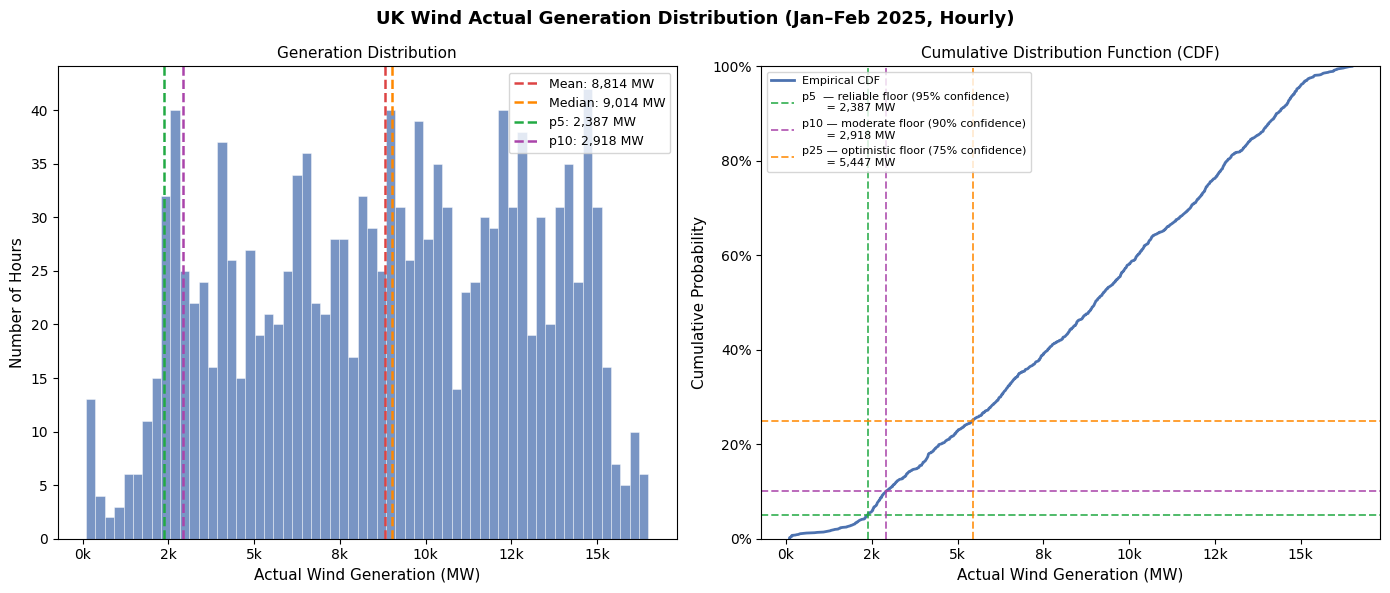

Plot saved to task_b_generation_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "UK Wind Actual Generation Distribution (Jan–Feb 2025, Hourly)",
    fontsize=13, fontweight="bold"
)

# --- Plot 1: Histogram ---
ax1 = axes[0]
ax1.hist(
    gen,
    bins=60,
    color="#4C72B0",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.4
)
ax1.axvline(gen.mean(),           color="#DD4444",  linestyle="--", linewidth=1.8, label=f"Mean: {gen.mean():,.0f} MW")
ax1.axvline(gen.median(),         color="#FF8800",  linestyle="--", linewidth=1.8, label=f"Median: {gen.median():,.0f} MW")
ax1.axvline(gen.quantile(0.05),   color="#22AA44",  linestyle="--", linewidth=1.8, label=f"p5: {gen.quantile(0.05):,.0f} MW")
ax1.axvline(gen.quantile(0.10),   color="#AA44AA",  linestyle="--", linewidth=1.8, label=f"p10: {gen.quantile(0.10):,.0f} MW")

ax1.set_xlabel("Actual Wind Generation (MW)", fontsize=11)
ax1.set_ylabel("Number of Hours", fontsize=11)
ax1.set_title("Generation Distribution", fontsize=11)
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")
)

# --- Plot 2: CDF ---
ax2 = axes[1]
sorted_gen = np.sort(gen.values)
cdf_y      = np.arange(1, len(sorted_gen) + 1) / len(sorted_gen)

ax2.plot(sorted_gen, cdf_y, color="#4C72B0", linewidth=2, label="Empirical CDF")

for pct, color, label in [
    (0.05, "#22AA44",  "p5  — reliable floor (95% confidence)"),
    (0.10, "#AA44AA",  "p10 — moderate floor (90% confidence)"),
    (0.25, "#FF8800",  "p25 — optimistic floor (75% confidence)"),
]:
    val = gen.quantile(pct)
    ax2.axhline(pct, color=color, linestyle="--", linewidth=1.4, alpha=0.8)
    ax2.axvline(val, color=color, linestyle="--", linewidth=1.4, alpha=0.8,
                label=f"{label}\n       = {val:,.0f} MW")

ax2.set_xlabel("Actual Wind Generation (MW)", fontsize=11)
ax2.set_ylabel("Cumulative Probability", fontsize=11)
ax2.set_title("Cumulative Distribution Function (CDF)", fontsize=11)
ax2.set_ylim(0, 1)
ax2.legend(fontsize=8, loc="upper left")
ax2.xaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")
)
ax2.yaxis.set_major_formatter(
    matplotlib.ticker.PercentFormatter(xmax=1.0)
)

plt.tight_layout()
plt.savefig("task_b_generation_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to task_b_generation_distribution.png")

## Task B — Business Recommendation: Reliable Wind Generation Floor

### Recommendation

**The UK grid can reliably plan around 2,387 MW of wind generation** as a committed
baseload-equivalent floor, with 95% historical confidence (p5 of Jan–Feb 2025 actuals).

---

### Reasoning Path

#### 1. Why not the mean (8,814 MW)?

The mean is the wrong planning metric for a volatile, non-dispatchable resource.
Wind generation has a coefficient of variation of 46.6% (std = 4,107 MW on a mean
of 8,814 MW). Planning around the mean means the grid falls short of its wind
commitment in roughly 50% of all hours — requiring emergency backup dispatch in
nearly one of every two hours. This is operationally and economically unacceptable.

#### 2. Why a percentile-based floor?

A percentile floor answers the operationally correct question:
> "What is the minimum MW of wind I can *commit to* with X% confidence?"

This reframes wind from an uncertain variable into a bounded reliability statement —
the same mental model used for firm capacity contracts in energy markets.

#### 3. Why p5 specifically?

The p5 (2,387 MW) means wind exceeded this level in **95% of all historical hours**.
This maps directly to a standard industry reliability criterion:

- **95% confidence** is a common threshold in capacity adequacy studies
  (e.g., LOLE — Loss of Load Expectation standards used by National Grid ESO).
- The alternative p10 (2,918 MW) reduces confidence to 90% — acceptable for
  operational planning but less appropriate for firm capacity commitments.
- The p1 (431 MW) is overly conservative; planning around near-zero wind
  means permanently over-procuring expensive standby gas capacity.

**p5 = 2,387 MW is the inflection point where confidence is high without being
wastefully conservative.**

#### 4. What this number means in practice

- UK total installed wind capacity (2025) is approximately 30,000 MW.
- Our p5 floor of 2,387 MW represents roughly **8% of installed capacity**.
- This means in the worst 5% of hours, wind is delivering less than 8% of
  its rated capacity — severe, extended wind droughts.
- Grid operators should size firm backup (gas peakers, interconnectors, demand
  response) to cover the remaining **~6,427 MW gap** between this floor and
  the minimum demand-side wind requirement.

#### 5. Interaction with Task A findings

The forecast error analysis (Task A) strengthens this recommendation:

- The WINDFOR model **over-predicts by a mean of 1,365 MW** (80.9% of forecasts).
- This means grid operators using WINDFOR at face value will *further* under-procure
  backup capacity — they believe more wind is coming than actually arrives.
- A grid operator should therefore apply a **bias correction of ~1,365 MW** to any
  WINDFOR forecast before committing to dispatch plans.
- Combined implication: if the model forecasts, say, 5,000 MW, the operator should
  plan for approximately 3,635 MW (5,000 - 1,365 bias correction), and hold backup
  capacity for the remaining shortfall relative to demand.

---

### Assumptions and Limitations

| Assumption | Impact if wrong |
|---|---|
| Jan–Feb 2025 is representative of typical wind conditions | Winter months have stronger, more variable wind than summer — p5 floor may be *lower* in summer; a full-year dataset would give a more conservative, robust floor |
| Hourly resolution is sufficient | 30-min resolution might reveal sub-hourly ramps not captured here; for intraday balancing, finer resolution matters |
| Historical distribution is stationary | Climate trends and

## Executive Summary

| | Finding |
|---|---|
| **Dataset** | Elexon BMRS WINDFOR + FUELHH, Jan–Feb 2025 (1,416 hourly actuals, 22,597 forecast records) |
| **Task A — Overall bias** | WINDFOR over-predicts by a mean of **1,365 MW** (80.9% of all forecasts are over-predictions) |
| **Task A — Worst case** | p99 absolute error = **5,486 MW** — in the worst 1% of forecasts, error exceeds 5.4 GW |
| **Task A — Horizon effect** | MAE grows from **1,360 MW (0–8h)** to **1,978 MW (40–48h)** — a 45% degradation |
| **Task A — Diurnal effect** | Overnight hours (00:00–06:00 UTC) have the **highest MAE (~1,900 MW)**; midday (12:00–14:00 UTC) the lowest (~1,370 MW) |
| **Task B — Reliable floor** | **p5 = 2,387 MW** — the MW level wind exceeded in 95% of all historical hours |
| **Task B — Key insight** | Wind has a 163x range (101–16,491 MW); the mean (8,814 MW) is an unreliable planning target |
| **Combined recommendation** | Apply a **−1,365 MW bias correction** to any WINDFOR forecast; plan firm backup capacity against a **2,387 MW wind floor**, not the forecast value |